In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, spearmanr, hypergeom
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    precision_score, recall_score, f1_score, silhouette_score,
)

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

sys.path.append('../..')
import sherlock as slk

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS         = 10   # was 5 — mentor wants 10-run boxplot
NUM_EPOCHS     = 600
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
N_CLUSTERS     = 10
RESULTS_DIR    = "results/reproducibility"

SHERLOCK_KWARGS = {
    "l0_lambda": 8.5,
    "ce_lambda": 20.0,
    "n_epochs_kl_warmup": 300.0,
    "n_epochs_l0_warmup": 350.0,
    "tau_end": 0.25,
    "rank": 8,
}

os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/matrices", exist_ok=True)
print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/reproducibility


## Data loading

In [5]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|████████████████████████████████████████████████████████████████████████| 681/681 [00:09<00:00, 70.89it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for cluster evaluation

In [6]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

# Flat table for merging (gene, pathway)
pathways_flat = pathway_df_indexed.reset_index()

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Cluster alignment helper

In [7]:
def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings=None,
    knn_k: int = 5,
    linear_probe_cv: int = 5,
):
    """Hungarian-match predicted clusters to ground-truth pathways.
    
    Embedding metrics (silhouette macro, kNN purity, linear probe) are
    computed via slk.tl.compute_embedding_metrics when gene_embeddings is provided.
    """
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how="inner", validate="one_to_one",
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, com, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    # Embedding-based metrics via shared helper
    sil = knn_pur = lin_probe = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        emb_metrics = slk.tl.compute_embedding_metrics(
            emb, y_true, knn_k=knn_k, linear_probe_cv=linear_probe_cv
        )
        sil       = emb_metrics["silhouette"]
        knn_pur   = emb_metrics["knn_purity"]
        lin_probe = emb_metrics["linear_probe"]

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        pur = (g[pathway_col] == majority).mean()
        rec_cl = (g[pathway_col] == majority).sum() / max((df[pathway_col] == majority).sum(), 1)
        purity_rows.append({"cluster": str(cl), "size": len(g),
                             "mapped_pathway": mapping.get(str(cl)), "purity": pur, "recall": rec_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    contingency = contingency_df.copy()
    row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    N_total = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes   = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N_total, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K,
                             "n": n, "N": N_total, "pval": float(pval)})
    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * max(len(enrich_df), 1), 1.0)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    df["mapped_pathway"] = mapped
    df["is_match"]       = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}),
        "mapping": mapping,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "ari": ari, "ami": ami,
        "homogeneity": hom, "completeness": com, "v_measure": vmeas,
        "silhouette": sil, "knn_purity": knn_pur, "linear_probe": lin_probe,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": row_norm,
        "contingency_col_norm": col_norm,
        "enrichment": enrich_df,
    }

## Reproducibility loop

Train Sherlock `N_RUNS` times independently. After each run extract:
- **W** — the (P × d) gate matrix from `model.gate(deterministic=True)`
- **rho_corr** — the (P × P) learned covariance correlation matrix
- **clusters** — hierarchical cut on the pathway-gene subset of rho_corr, then Hungarian-matched to pathways via `align_and_summarize`

In [8]:
use_rerun = True

for run in range(N_RUNS):
    out_path = f'{RESULTS_DIR}/matrices/run_{run}.npz'
    if os.path.exists(out_path) and use_rerun:
        print(f'Run {run+1}: already saved, skipping.')
        continue

    print(f"\n{'='*50}\nReplogle run {run+1}/{N_RUNS}\n{'='*50}")
    out   = slk.tl.run(
        data,
        model="vae",
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        device=DEVICE,
        latent_dim=LATENT_DIM,
        patience=PATIENCE,
        validate_every=VALIDATE_EVERY,
        seed=run,
        **SHERLOCK_KWARGS,
    )
    model = out['model']
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    res = data.uns['results']

    W         = np.asarray(res['W'],        dtype=float) if 'W' in res else model.gate(deterministic=True).detach().cpu().numpy()
    rho_corr  = np.asarray(res['z_corr'],   dtype=float)
    rho_perts = np.asarray(res['rho_perts'])

    # counterfactual_effect_size: shape (1, P, G) for Replogle (single condition)
    # flatten to (P, G) for storage
    cf_raw = np.asarray(res['counterfactual_effect_size'], dtype=float)
    if cf_raw.ndim == 3:
        cf_raw = cf_raw[0]   # (P, G)

    # ATE
    ate_metrics = slk.tl.compute_cf_ate_metrics(model, data, treat_effect_adata)
    ate_r = float(ate_metrics['cf_ate_pearson_r'])

    # Save flat files
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_W.npy',        W)
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy', rho_corr)
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt', rho_perts, fmt='%s')
    np.savetxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt', [ate_r],   fmt='%.6f')
    np.save(f'{RESULTS_DIR}/matrices/run_{run}_cf.npy',       cf_raw)    # (P, G)
    np.savez(out_path)   # sentinel

    print(f'  Saved run {run+1} (ATE r={ate_r:.4f})')

    if 'out' in locals(): del out
    if 'model' in locals(): del model
    import gc, torch
    torch.cuda.empty_cache()
    gc.collect()

print('\nTraining complete.')

Run 1: already saved, skipping.
Run 2: already saved, skipping.
Run 3: already saved, skipping.
Run 4: already saved, skipping.
Run 5: already saved, skipping.
Run 6: already saved, skipping.

Replogle run 7/10
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  Saved run 7 (ATE r=0.5651)

Replogle run 8/10
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  Saved run 8 (ATE r=0.5756)

Replogle run 9/10
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  Saved run 9 (ATE r=0.5825)

Replogle run 10/10
Training VAE on cuda …


Epochs:   0%|                                                                          | 0/600 [00:00<?, ?it/s…

  Saved run 10 (ATE r=0.5312)

Training complete.


## Per-run clustering metrics

In [9]:
run_results = []
for run in range(N_RUNS):
    W         = np.load(f'{RESULTS_DIR}/matrices/run_{run}_W.npy')
    rho_corr  = np.load(f'{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy')
    rho_perts = np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_perts.txt', dtype=str, ndmin=1)
    ate_r     = float(np.loadtxt(f'{RESULTS_DIR}/matrices/run_{run}_ate_r.txt'))
    cf_raw    = np.load(f'{RESULTS_DIR}/matrices/run_{run}_cf.npy')   # (P, G)

    run_results.append(dict(
        run=run, W=W, rho_corr=rho_corr,
        rho_perts=rho_perts, ate_r=ate_r, cf_raw=cf_raw,
    ))
    print(f'Run {run+1}: ATE r={ate_r:.4f}  W {W.shape}  perts {len(rho_perts)}')

all_perts  = sorted(run_results[0]['rho_perts'].tolist())
all_ate_r  = [r['ate_r'] for r in run_results]
print(f'\nATE r — Mean ± Std: {np.mean(all_ate_r):.4f} ± {np.std(all_ate_r):.4f}')

# Re-establish your exact expected metrics dataframe structure
# metrics_df = pd.DataFrame(per_run_metrics).set_index('run').sort_index()
# print("\n" + metrics_df.round(4).to_string())

# print("\nMean ± Std:")
# for col in metrics_df.columns:
#     v = pd.to_numeric(metrics_df[col], errors='coerce').dropna().values
#     if len(v) > 0:
#         print(f"  {col:15s}: {np.mean(v):.4f} ± {np.std(v):.4f}")
#     else:
#         print(f"  {col:15s}: N/A")

Run 1: ATE r=0.5770  W (681, 16)  perts 681
Run 2: ATE r=0.5675  W (681, 16)  perts 681
Run 3: ATE r=0.5785  W (681, 16)  perts 681
Run 4: ATE r=0.6160  W (681, 16)  perts 681
Run 5: ATE r=0.5652  W (681, 16)  perts 681
Run 6: ATE r=0.5341  W (681, 16)  perts 681
Run 7: ATE r=0.5651  W (681, 16)  perts 681
Run 8: ATE r=0.5756  W (681, 16)  perts 681
Run 9: ATE r=0.5825  W (681, 16)  perts 681
Run 10: ATE r=0.5312  W (681, 16)  perts 681

ATE r — Mean ± Std: 0.5693 ± 0.0229


## Pairwise similarity metrics

For each pair of runs compute:

1. **W correlation** — Pearson r between upper triangles of `W @ Wᵀ` (co-activation matrices, invariant to latent-dim permutation).

2. **Covariance correlation** — Pearson r between upper triangles of `rho_corr`.

3. **Cluster Jaccard (defined)** — Jaccard co-membership similarity using the raw hierarchical cluster integer labels (permutation-invariant by construction).

4. **Cluster Jaccard (matched)** — Same co-membership Jaccard but using the **Hungarian-matched** pathway labels, so identical names mean the same pathway in both runs.
   $$J = \frac{|\{(i,j): \text{same label in both runs}\}|}{|\{(i,j): \text{same label in at least one run}\}|}$$

In [10]:
def _jaccard_comembership(labels_i, labels_j):
    n = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


pairs       = list(combinations(range(N_RUNS), 2))
w_corrs     = []
rho_corrs   = []
jac_raw     = []   # renamed from jaccard_defined — only unsupervised

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # W co-activation
    Ci = ri['W'] @ ri['W'].T
    Cj = rj['W'] @ rj['W'].T
    triu = np.triu_indices(Ci.shape[0], k=1)
    w_corrs.append(pearsonr(Ci[triu], Cj[triu])[0])

    # rho_corr
    fi, fj = ri['rho_corr'][triu], rj['rho_corr'][triu]
    valid  = np.isfinite(fi) & np.isfinite(fj)
    rho_corrs.append(pearsonr(fi[valid], fj[valid])[0])

    # Jaccard (unsupervised raw clusters only)
    # need to cluster first — see cluster cell below

pair_labels = [f"run{i+1}–run{j+1}" for i, j in pairs]
print(f"W co-act  — Mean ± Std: {np.mean(w_corrs):.4f} ± {np.std(w_corrs):.4f}")
print(f"rho_corr  — Mean ± Std: {np.mean(rho_corrs):.4f} ± {np.std(rho_corrs):.4f}")

W co-act  — Mean ± Std: 0.9573 ± 0.0050
rho_corr  — Mean ± Std: 0.8403 ± 0.0348


In [11]:
# Cluster each run's rho_corr
clustered_runs = []
for rr in run_results:
    groups = slk.tl.cluster_rho(
        data, t=N_CLUSTERS, rho_corr=rr['rho_corr'],
        criterion='maxclust', show=False,
    )
    clustered_runs.append({**rr, 'groups': groups})

# Now compute Jaccard
jac_raw = []
for idx, (i, j) in enumerate(pairs):
    gi = clustered_runs[i]['groups'].astype(object)
    gj = clustered_runs[j]['groups'].astype(object)
    jac_raw.append(_jaccard_comembership(gi, gj))

print(f"Jaccard (unsupervised) — Mean ± Std: {np.mean(jac_raw):.4f} ± {np.std(jac_raw):.4f}")

Jaccard (unsupervised) — Mean ± Std: 0.4299 ± 0.0453


In [12]:
# ── CPI: Condition-Perturbation Interaction (pairwise Spearman of CF effect sizes) ──
# Replogle has 1 condition, so cf_raw is (P, G): perturbation × gene effect sizes.
# We correlate the flattened P×G matrix between every pair of runs.

def modified_z_score(x):
    """Robust z-score using MAD: (x - median) / (1.4826 * MAD)"""
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return (x - med) / (1.4826 * mad + 1e-12)

cpi_raw_spearman = []      # Spearman on raw counterfactual_effect_size
cpi_zscore_spearman = []   # Spearman on modified z-score values

for i, j in pairs:
    xi = run_results[i]['cf_raw'].ravel()   # (P*G,)
    xj = run_results[j]['cf_raw'].ravel()

    valid = np.isfinite(xi) & np.isfinite(xj)
    xi_v, xj_v = xi[valid], xj[valid]

    # Raw
    cpi_raw_spearman.append(spearmanr(xi_v, xj_v)[0])

    # Modified z-score (applied per run before comparison)
    xi_z = modified_z_score(xi_v)
    xj_z = modified_z_score(xj_v)
    cpi_zscore_spearman.append(spearmanr(xi_z, xj_z)[0])

print("CPI (raw cf effect size) Spearman ρ:")
print(f"  Mean ± Std: {np.nanmean(cpi_raw_spearman):.4f} ± {np.nanstd(cpi_raw_spearman):.4f}")
print("\nCPI (modified z-score) Spearman ρ:")
print(f"  Mean ± Std: {np.nanmean(cpi_zscore_spearman):.4f} ± {np.nanstd(cpi_zscore_spearman):.4f}")

CPI (raw cf effect size) Spearman ρ:
  Mean ± Std: 0.5481 ± 0.0340

CPI (modified z-score) Spearman ρ:
  Mean ± Std: 0.5481 ± 0.0340


## Visualization

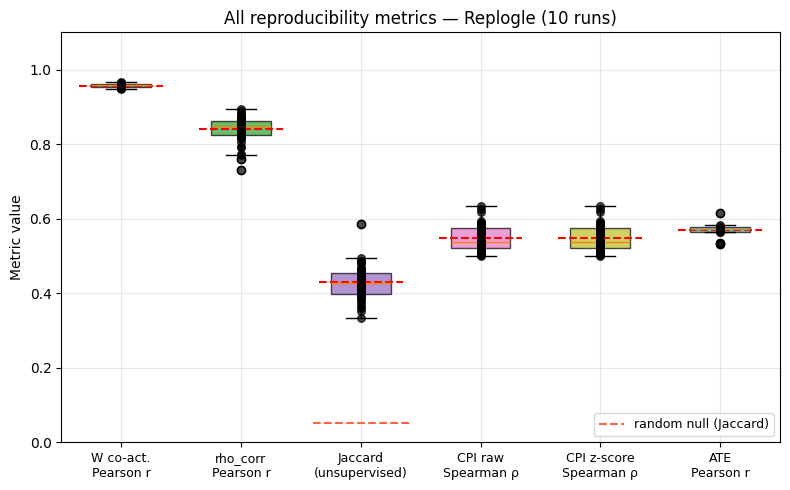

In [13]:
ate_values = all_ate_r   # one per run (not pairwise) — plotted as-is

# Build null baselines for Jaccard metrics
G = data.n_vars
jac_null  = 1 / (2 * N_CLUSTERS - 1)   # random chance for cluster Jaccard

metric_labels = [
    'W co-act.\nPearson r',
    'rho_corr\nPearson r',
    'Jaccard\n(unsupervised)',
    'CPI raw\nSpearman ρ',
    'CPI z-score\nSpearman ρ',
    'ATE\nPearson r',
]
metric_vals = [
    w_corrs,
    rho_corrs,
    jac_raw,
    cpi_raw_spearman,
    cpi_zscore_spearman,
    ate_values,
]
# Which metrics have a Jaccard null line
jac_null_map = {
    'Jaccard\n(unsupervised)': jac_null,
}

n_m = len(metric_labels)
fig, ax = plt.subplots(figsize=(max(8, n_m * 1.1), 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_m))

for pos, (label, vals, col) in enumerate(zip(metric_labels, metric_vals, colors), 1):
    clean = [v for v in vals if np.isfinite(v)]
    if not clean:
        continue
    ax.boxplot(clean, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.7))
    ax.scatter([pos]*len(clean), clean, s=30, color='k', zorder=3, alpha=0.7)
    m = np.mean(clean)
    ax.plot([pos-0.35, pos+0.35], [m, m], 'r--', lw=1.5)

    if label in jac_null_map:
        ax.plot([pos-0.4, pos+0.4], [jac_null_map[label]]*2,
                color='tomato', lw=1.5, ls='--', zorder=4)

ax.plot([], [], color='tomato', lw=1.5, ls='--', label='random null (Jaccard)')
ax.legend(fontsize=9, loc='lower right')
ax.set_xticks(range(1, n_m + 1))
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Metric value')
ax.set_title(f'All reproducibility metrics — Replogle ({N_RUNS} runs)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/all_metrics_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()